# Train (20-pulse, 20 Hz) Summary Figure

Eight-panel summary of the 20-pulse, 20 Hz train across 4 conditions --
Control, Control + ER blocked, AD + 5x RyR, AD + ER blocked. Four rows,
two columns.

- **a/b**: Facilitation vs Pulse Number -- Control pair (Control vs
  Control + ER blocked) / AD pair (AD + 5x RyR vs AD + ER blocked), same
  y-scale so the two panels stay comparable
- **c**: Peak ER [Ca$^{2+}$] vs Pulse Number -- all 4 conditions; steepest
  single-pulse depletion marked for Control / AD + 5x RyR only (the
  ER-blocked conditions barely deplete, so their "steepest drop" isn't a
  meaningful point to call out)
- **d**: Net RyR Ca$^{2+}$ flux vs time -- all 4 conditions; time-to-half-rise
  marked for Control / AD + 5x RyR only, same reasoning as c
- **e**: Peak Cytosolic [Ca$^{2+}$] vs Pulse Number -- Control + ER blocked
  vs AD + ER blocked (the two ER-blocked conditions overlaid, isolating
  the AD-vs-control difference within the ER-blocked background)
- **f**: Peak AZ [Ca$^{2+}$] vs Pulse Number -- Control + ER blocked vs
  AD + ER blocked, same rationale as panel e
- **g**: Release Probability vs Pulse Number -- all 4 conditions
- **h**: RRP size vs Pulse Number (value just before each pulse, from
  `rrp.dat`) -- all 4 conditions

All conditions use `plot_config.py`'s shared colors/markers. See the data
notes and CONFIG cells below for the directory-selection history and
known data caveats.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    set_n_ticks,
    save_figure,
)

apply_style()


In [2]:
# ============================================================
# CONFIG -- train stimulus (20 pulses, 20 Hz)
# ============================================================

TRAIN_ORDER = ["control", "control_er_blocked", "ad_5x_ryr", "ad_er_blocked"]

CONTROL_PAIR = ["control", "control_er_blocked"]
AD_PAIR = ["ad_5x_ryr", "ad_er_blocked"]

ER_BLOCKED_PAIR = ["control_er_blocked", "ad_er_blocked"]

RING_MARK_CONDITIONS = ["control", "ad_5x_ryr"]

N_PULSES = 20
FREQ_HZ = 20
FIRST_PULSE_TIME = 0.002  # s

MARKERSIZE = 6
CAPSIZE = 3
ELINEWIDTH = 1.2

N_TICKS = 3
PULSE_XTICKS = [1, N_PULSES // 2, N_PULSES]


In [3]:
# ============================================================
# DATA LOADING -- functions
# ============================================================


def load_trace(fname):
    """Return (time_s, value) for a two-column whitespace-delimited trace."""
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1]


def load_ryr_flux(fname):
    """ryrCaFlux.dat: col0=time(s), col1=outflux, col2=influx (molecules/s).
    Net flux = outflux - influx (Ca_flux/RyRcaflux.ipynb convention)."""
    data = np.loadtxt(fname)
    t = data[:, 0]
    net = data[:, 1] - data[:, 2]
    return t, net


def load_vesrel_cumulative(fname, first_pulse_time, freq, n_pulses, t_end=1.0,
                            n_trials=None):
    """vesRel: time(s) dx dy dz tag -- every release event (sync + async,
    all release sites) from every trial's rel.dat, concatenated into one
    file (per modFuncNew.py's relptp/relppf convention. Bin event count into
    the same per-pulse windows as extract_pulse_peaks/_pulse_windows, then
    take the running cumulative sum across pulses.

    `n_trials` divides the counts to give cumulative vesicles released
    PER TRIAL. Pass None to keep raw summed counts."""
    
    times = np.loadtxt(fname, usecols=0)
    starts, ends = _pulse_windows(first_pulse_time, freq, n_pulses, t_end)
    per_pulse_counts = np.array([
        np.sum((times >= t0) & (times < t1)) for t0, t1 in zip(starts, ends)
    ])
    cumulative = np.cumsum(per_pulse_counts)
    if n_trials is not None:
        cumulative = cumulative / float(n_trials)
    return cumulative


def _pulse_windows(first_pulse_time, freq, n_pulses, t_end):
    """(start, end) time window per pulse -- last window extends to t_end."""
    isi = 1.0 / freq
    starts = first_pulse_time + np.arange(n_pulses) * isi
    ends = np.append(starts[1:], t_end)
    return starts, ends


def extract_pulse_peaks(time, trace, first_pulse_time, freq, n_pulses):
    """Peak trace value within each pulse's window."""
    starts, ends = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    peaks = []
    for t0, t1 in zip(starts, ends):
        mask = (time >= t0) & (time < t1)
        peaks.append(np.max(trace[mask]) if np.any(mask) else np.nan)
    return np.asarray(peaks)


def extract_pulse_baselines(time, trace, first_pulse_time, freq, n_pulses):
    """Trace value at the sample immediately preceding each pulse onset."""
    starts, _ = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    baselines = []
    for t0 in starts:
        idx = max(np.searchsorted(time, t0) - 1, 0)
        baselines.append(trace[idx])
    return np.asarray(baselines)


In [4]:
# ============================================================
# FIGURE-BUILDING HELPERS
# ============================================================


def apply_xticks(ax, key, vmin, vmax, ticks=None):
    ticks = ticks if ticks is not None else X_TICKS
    override = ticks.get(key)
    if override is not None:
        ax.set_xticks(override)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="x")


def apply_yticks(ax, key, vmin, vmax, ticks=None):
    ticks = ticks if ticks is not None else Y_TICKS
    override = ticks.get(key)
    if override is not None:
        ax.set_yticks(override)
        pad = 0.05 * (max(override) - min(override))
        ax.set_ylim(min(override) - pad, max(override) + pad)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="y")


def trace_panel(ax, letter, field, ylabel, tick_key, keys=None, y_range=None,
                 letter_y=1.05, data=None, ticks_x=None, ticks_y=None):
    """Single trace vs pulse, one line per condition in `keys` (default:
    all of TRAIN_ORDER)."""
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    for key in keys:
        cond = get_condition(key)
        ax.plot(
            pulses, data[key][field],
            color=cond.color, linestyle="-", marker=cond.marker,
            markersize=MARKERSIZE, markerfacecolor=cond.color, markeredgecolor=cond.color,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel(ylabel)
    apply_xticks(ax, tick_key, pulses.min(), pulses.max(), ticks=ticks_x)
    if y_range is None:
        all_y = np.concatenate([data[k][field] for k in keys])
        y_range = (all_y.min(), all_y.max())
    apply_yticks(ax, tick_key, y_range[0], y_range[1], ticks=ticks_y)
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter, y=letter_y)


def stat_panel(ax, letter, y_field, y_sd_field, ylabel, tick_key, keys=None, y_range=None,
               data=None, ticks_x=None, ticks_y=None):
    """Connected line + error bars vs pulse, one line per condition in
    `keys` (default: all of TRAIN_ORDER)."""
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    for key in keys:
        cond = get_condition(key)
        y = data[key][y_field]
        yerr = data[key][y_sd_field]
        ax.errorbar(
            pulses, y, yerr=yerr,
            color=cond.color, marker=cond.marker, linestyle=cond.linestyle,
            markersize=MARKERSIZE, capsize=CAPSIZE, elinewidth=ELINEWIDTH,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel(ylabel)
    apply_xticks(ax, tick_key, pulses.min(), pulses.max(), ticks=ticks_x)
    if y_range is None:
        y_all = np.concatenate([data[k][y_field] for k in keys])
        y_range = (y_all.min(), y_all.max())
    apply_yticks(ax, tick_key, y_range[0], y_range[1], ticks=ticks_y)
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter)


def flux_trace_panel(ax, letter, t_field, y_field, ylabel, tick_key, keys=None,
                      letter_x=-0.18, linestyle_override=None, zero_line=False,
                      y_bottom_frac=0.08, data=None, ticks_x=None, ticks_y=None):
    """Raw continuous time-domain trace, one line per condition in `keys`
    (default: all of TRAIN_ORDER)."""
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    linestyle_override = linestyle_override or {}
    for key in keys:
        cond = get_condition(key)
        ls = linestyle_override.get(key, cond.linestyle)
        ax.plot(
            data[key][t_field], data[key][y_field],
            color=cond.color, linestyle=ls,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel)
    all_t = np.concatenate([data[k][t_field] for k in keys])
    apply_xticks(ax, tick_key, all_t.min(), all_t.max(), ticks=ticks_x)
    all_y = np.concatenate([data[k][y_field] for k in keys])
    y_max = all_y.max()
    apply_yticks(ax, tick_key, 0.0, y_max, ticks=ticks_y)
    if zero_line:
        ax.set_ylim(bottom=-y_bottom_frac * y_max)
        ax.axhline(0, color="0.6", linestyle="--", linewidth=1.0, zorder=0.5)
    else:
        ax.set_ylim(bottom=0)
    strip_spines(ax)
    label_panel(ax, letter, x=letter_x)


In [5]:
ISI_S = 1.0 / FREQ_HZ
pulses = np.arange(1, N_PULSES + 1)


In [6]:
TRAIN_DIRS_V80 = {
    "control": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C250uM_20_p20hz_8_10_serca"
    ),
    "control_er_blocked": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C250uM_20_p20hz_8_10_serca_RSB"
    ),
    "ad_5x_ryr": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C750uM_20_p20hz_5xryr_8_10xserca"
    ),
    "ad_er_blocked": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C750uM_20_p20hz_5xryr_8_10xserca_RSB"
    ),
}

N_TRIALS_V80 = 2000

X_TICKS_V80 = {
    "fac_vs_pulse": PULSE_XTICKS,
    "pr_vs_pulse": PULSE_XTICKS,
    "cyto_peak": PULSE_XTICKS,
    "er_peak": PULSE_XTICKS,
    "az_peak": PULSE_XTICKS,
    "vesrel_cumulative": PULSE_XTICKS,
    "rrp": PULSE_XTICKS,
    "ryr_flux": None,
}
Y_TICKS_V80 = {
    "fac_vs_pulse": None,
    "pr_vs_pulse": None,
    "cyto_peak": None,
    "er_peak": None,
    "az_peak": None,
    "vesrel_cumulative": None,
    "rrp": [0, 3.5, 7],
    "ryr_flux": None,
}


In [7]:
def load_result_auto(fname):
    """Load a `result` file in either known layout, detecting which from
    its shape and then validating the decoded values actually look like
    Pr/facilitation before returning them.

    Layouts seen in this project:
      (2, 40) -- row 0 = means, row 1 = stds, each [Pr(20), Facilitation(20)]
      (20, 5) -- col0=pulse#, col1=pr_mean, col2=pr_sd, col3=fac_mean, col4=fac_sd"""
    data = np.loadtxt(fname)
    if data.shape == (2, 40):
        means, stds = data[0], data[1]
        out = {
            "pr_mean": means[:20], "pr_sd": stds[:20],
            "fac_mean": means[20:], "fac_sd": stds[20:],
        }
    elif data.shape == (20, 5):
        out = {
            "pr_mean": data[:, 1], "pr_sd": data[:, 2],
            "fac_mean": data[:, 3], "fac_sd": data[:, 4],
        }
    else:
        raise ValueError(f"{fname}: unrecognised result shape {data.shape}")

    pr, fac = out["pr_mean"], out["fac_mean"]
    if pr.min() < 0 or pr.max() > 1:
        raise ValueError(
            f"{fname}: decoded release probability outside [0, 1] "
            f"(range {pr.min():.3f}-{pr.max():.3f}) -- shape matched "
            f"{data.shape} but the column layout does not."
        )
    if abs(fac[0] - 1.0) > 1e-6:
        raise ValueError(
            f"{fname}: decoded facilitation[0] = {fac[0]:.3f}, expected "
            "exactly 1.0 -- column layout does not match this shape."
        )
    return out


def load_ptp(fname):
    return np.loadtxt(fname)


train_data_v80 = {}

for key in TRAIN_ORDER:
    directory = TRAIN_DIRS_V80[key]

    t_az, az = load_trace(directory / "CaConc")
    t_cyto, cyto = load_trace(directory / "pre_ca_conc.dat")
    cyto = cyto / 1000.0  # nM -> uM
    t_er, er = load_trace(directory / "er_ca_conc.dat")
    t_ryr, ryr_flux = load_ryr_flux(directory / "ryrCaFlux.dat")
    vesrel_cumulative = load_vesrel_cumulative(
        directory / "vesRel", FIRST_PULSE_TIME, FREQ_HZ, N_PULSES,
        n_trials=N_TRIALS_V80,
    )
    t_rrp, rrp = load_trace(directory / "rrp.dat")

    result = load_result_auto(directory / "result")
    result["fac_mean"] = load_ptp(directory / "ptp")

    train_data_v80[key] = {
        "az_peak": extract_pulse_peaks(t_az, az, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "cyto_peak": extract_pulse_peaks(t_cyto, cyto, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "er_peak": extract_pulse_peaks(t_er, er, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "vesrel_cumulative": vesrel_cumulative,
        "rrp": extract_pulse_baselines(t_rrp, rrp, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "ryr_flux_t_ms": t_ryr * 1000.0,
        "ryr_flux": ryr_flux / 100.0,  # molecules/s -> x100 molecules/s
        **result,
    }


In [8]:
# ============================================================
# ER DEPLETION RATE + RyR FLUX HALF-RISE -- VDCC = 80
# ============================================================

depletion_info_v80 = {}
print("VDCC=80 -- Peak ER Ca depletion rate (steepest single-pulse drop):")
for key in TRAIN_ORDER:
    cond = get_condition(key)
    er_peak = train_data_v80[key]["er_peak"]
    per_pulse_drop = -np.diff(er_peak)
    steepest = np.argmax(per_pulse_drop)
    rate_per_pulse = per_pulse_drop[steepest]
    rate_per_s = rate_per_pulse / ISI_S
    depletion_info_v80[key] = {
        "steepest_idx": steepest,
        "rate_per_pulse": rate_per_pulse,
        "rate_per_s": rate_per_s,
    }
    print(
        f"  {cond.label}: {rate_per_pulse:.2f} uM/pulse "
        f"({rate_per_s:.1f} uM/s), steepest between pulse "
        f"{steepest + 1} and {steepest + 2}"
    )

half_rise_info_v80 = {}
print("VDCC=80 -- RyR net flux: time to half-rise:")
for key in TRAIN_ORDER:
    cond = get_condition(key)
    t_ms = train_data_v80[key]["ryr_flux_t_ms"]
    y = train_data_v80[key]["ryr_flux"]
    half = y[-1] / 2.0
    idx = int(np.argmax(y >= half))
    half_rise_info_v80[key] = {"t_ms": t_ms[idx], "y": y[idx]}
    print(f"  {cond.label}: {t_ms[idx]:.1f} ms")


VDCC=80 -- Peak ER Ca depletion rate (steepest single-pulse drop):
  Control: 35.30 uM/pulse (706.0 uM/s), steepest between pulse 3 and 4
  Control + ER blocked: 0.70 uM/pulse (14.1 uM/s), steepest between pulse 18 and 19
  AD + 5× RyR: 269.69 uM/pulse (5393.7 uM/s), steepest between pulse 2 and 3
  AD + ER blocked: 1.42 uM/pulse (28.4 uM/s), steepest between pulse 19 and 20
VDCC=80 -- RyR net flux: time to half-rise:
  Control: 257.8 ms
  Control + ER blocked: 687.7 ms
  AD + 5× RyR: 97.6 ms
  AD + ER blocked: 811.9 ms


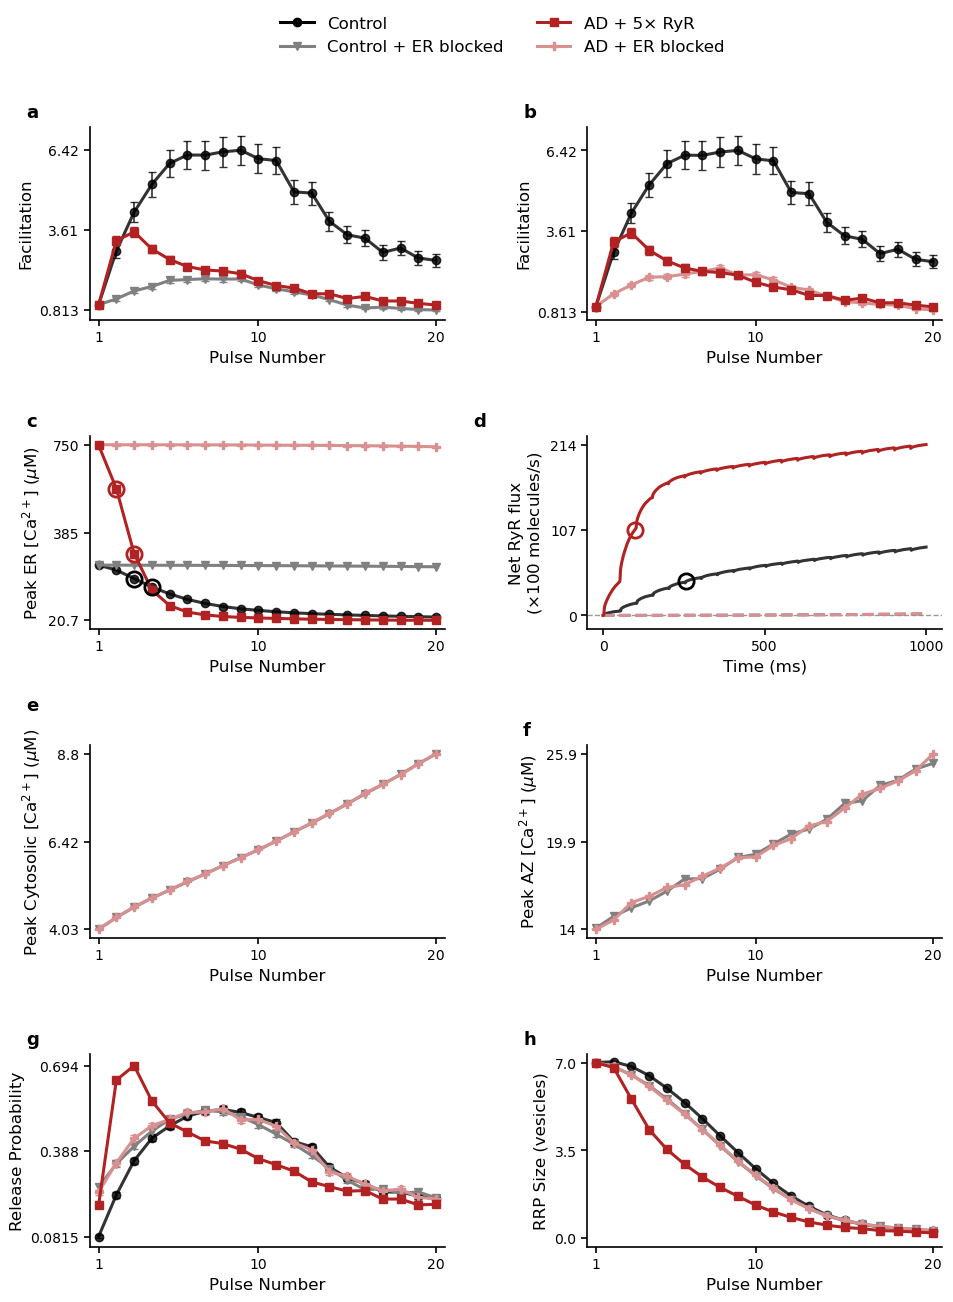

In [9]:
# ============================================================
# FIGURE -- VDCC = 80. 8 panels, 4 rows x 2 cols.
# ============================================================

FIGSIZE_V80 = (11, 14)
SAVE_NAME_V80 = "fig7_ER_hyperactivity.png"

fig_v80, axes_v80 = plt.subplots(4, 2, figsize=FIGSIZE_V80)
fig_v80.subplots_adjust(hspace=0.6, wspace=0.4, top=0.91)

fac_all_v80 = np.concatenate([train_data_v80[k]["fac_mean"] for k in TRAIN_ORDER])
fac_range_v80 = (fac_all_v80.min(), fac_all_v80.max())

CONTROL_PAIR_PLUS_AD = CONTROL_PAIR + ["ad_5x_ryr"]
AD_PAIR_PLUS_CONTROL = AD_PAIR + ["control"]

stat_panel(
    axes_v80[0, 0], "a", "fac_mean", "fac_sd", "Facilitation", "fac_vs_pulse",
    keys=CONTROL_PAIR_PLUS_AD, y_range=fac_range_v80,
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)
stat_panel(
    axes_v80[0, 1], "b", "fac_mean", "fac_sd", "Facilitation", "fac_vs_pulse",
    keys=AD_PAIR_PLUS_CONTROL, y_range=fac_range_v80,
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)

trace_panel(
    axes_v80[1, 0], "c", "er_peak", r"Peak ER [Ca$^{2+}$] ($\mu$M)", "er_peak",
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)
for key in RING_MARK_CONDITIONS:
    cond = get_condition(key)
    idx = depletion_info_v80[key]["steepest_idx"]
    axes_v80[1, 0].plot(
        pulses[idx:idx + 2], train_data_v80[key]["er_peak"][idx:idx + 2],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

flux_trace_panel(
    axes_v80[1, 1], "d", "ryr_flux_t_ms", "ryr_flux",
    "Net RyR flux\n" + r"($\times$100 molecules/s)", "ryr_flux",
    letter_x=-0.32,
    linestyle_override={"control_er_blocked": "--", "ad_er_blocked": "--"},
    zero_line=True,
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)
for key in RING_MARK_CONDITIONS:
    cond = get_condition(key)
    info = half_rise_info_v80[key]
    axes_v80[1, 1].plot(
        info["t_ms"], info["y"],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

trace_panel(
    axes_v80[2, 0], "e", "cyto_peak", r"Peak Cytosolic [Ca$^{2+}$] ($\mu$M)", "cyto_peak",
    keys=ER_BLOCKED_PAIR, letter_y=1.18,
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)
trace_panel(
    axes_v80[2, 1], "f", "az_peak", r"Peak AZ [Ca$^{2+}$] ($\mu$M)", "az_peak",
    keys=ER_BLOCKED_PAIR,
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)

stat_panel(
    axes_v80[3, 0], "g", "pr_mean", "pr_sd", "Release Probability", "pr_vs_pulse",
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)

# ------------------------------------------------------------------
# Panel h: RRP size vs Pulse 
# ------------------------------------------------------------------
trace_panel(
    axes_v80[3, 1], "h", "rrp", "RRP Size (vesicles)", "rrp",
    data=train_data_v80, ticks_x=X_TICKS_V80, ticks_y=Y_TICKS_V80,
)

train_handles_v80 = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           linestyle="-", markersize=MARKERSIZE, label=get_condition(k).label)
    for k in TRAIN_ORDER
]
fig_v80.legend(
    handles=train_handles_v80, loc="upper center", ncol=2,
    frameon=False, bbox_to_anchor=(0.5, 1.0),
    title_fontsize=9,
)

save_figure(fig_v80, SAVE_NAME_V80)
plt.show()


VDCC=80 -- Facilitation curve fits (rise-and-decay model):
  Control: A=52.14, tau_rise=20.00 pulses, tau_decay=6.25 pulses, R^2=0.948
  Control + ER blocked: A=12.26, tau_rise=20.00 pulses, tau_decay=3.89 pulses, R^2=0.728
  AD + 5× RyR: A=3.61, tau_rise=0.71 pulses, tau_decay=5.57 pulses, R^2=0.979
  AD + ER blocked: A=16.28, tau_rise=20.00 pulses, tau_decay=4.31 pulses, R^2=0.825


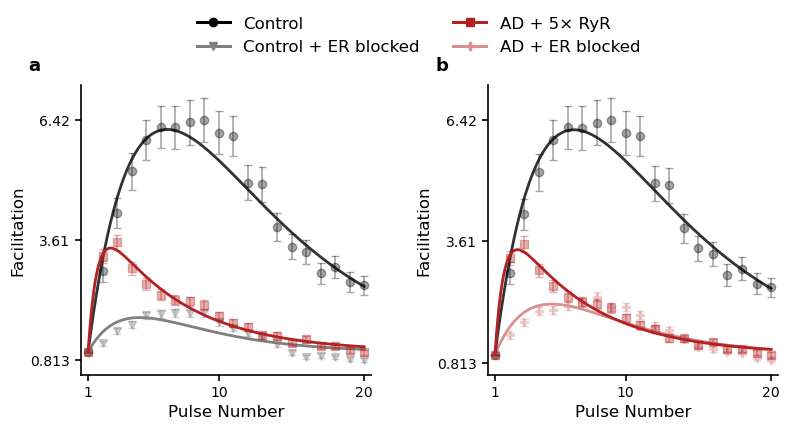

In [10]:
# ============================================================
# FACILITATION CURVE FITS -- panels a & b
#
# The facilitation-vs-pulse curves rise to a peak and then decay over
# the rest of the train. Fit each condition with a 3-parameter
# rise-and-decay model, pinned to f(pulse 1) = 1 by construction
# (matches the normalisation of the raw data exactly):
#
#   f(t) = 1 + A * exp(-t / tau_decay) * (1 - exp(-t / tau_rise))
#
# where t = pulse_number - 1. A = amplitude, tau_rise = build-up
# timescale, tau_decay = decay timescale (both in units of pulses).
# ============================================================

from scipy.optimize import curve_fit


def facilitation_model(x, A, tau_rise, tau_decay):
    t = x - 1
    return 1.0 + A * np.exp(-t / tau_decay) * (1.0 - np.exp(-t / tau_rise))


FAC_FIT_P0 = [1.0, 2.0, 10.0]
FAC_FIT_BOUNDS = ([0.0, 0.1, 0.5], [100.0, 20.0, 50.0])

fac_fits_v80 = {}
pulses_dense = np.linspace(pulses.min(), pulses.max(), 200)

print("VDCC=80 -- Facilitation curve fits (rise-and-decay model):")
for key in TRAIN_ORDER:
    cond = get_condition(key)
    y = train_data_v80[key]["fac_mean"]
    yerr = train_data_v80[key]["fac_sd"]
    # fac_sd[0] is exactly 0 (pulse 1 is the normalisation reference) --
    # floor it at the smallest nonzero sd so that point doesn't get
    # infinite weight in the fit.
    sigma = np.where(yerr > 0, yerr, yerr[yerr > 0].min())

    popt, _ = curve_fit(
        facilitation_model, pulses, y, p0=FAC_FIT_P0, sigma=sigma,
        absolute_sigma=True, bounds=FAC_FIT_BOUNDS, maxfev=40000,
    )
    y_fit = facilitation_model(pulses, *popt)
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    fac_fits_v80[key] = {"popt": popt, "r2": r2}
    print(
        f"  {cond.label}: A={popt[0]:.2f}, tau_rise={popt[1]:.2f} pulses, "
        f"tau_decay={popt[2]:.2f} pulses, R^2={r2:.3f}"
    )

# ------------------------------------------------------------------
# Overlay fitted curves on panels a & b (data faded, fit solid)
# ------------------------------------------------------------------
fig_fit, axes_fit = plt.subplots(1, 2, figsize=(9, 4.2))
fig_fit.subplots_adjust(wspace=0.4, top=0.8)

for ax, letter, keys in zip(
    axes_fit, ["a", "b"], [CONTROL_PAIR_PLUS_AD, AD_PAIR_PLUS_CONTROL]
):
    for key in keys:
        cond = get_condition(key)
        y = train_data_v80[key]["fac_mean"]
        yerr = train_data_v80[key]["fac_sd"]
        ax.errorbar(
            pulses, y, yerr=yerr,
            color=cond.color, marker=cond.marker, linestyle="none",
            markersize=MARKERSIZE, capsize=CAPSIZE, elinewidth=ELINEWIDTH,
            alpha=0.35, zorder=cond.zorder,
        )
        y_fit_dense = facilitation_model(pulses_dense, *fac_fits_v80[key]["popt"])
        ax.plot(
            pulses_dense, y_fit_dense,
            color=cond.color, linestyle="-", linewidth=2,
            alpha=cond.alpha, zorder=cond.zorder + 1,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel("Facilitation")
    apply_xticks(ax, "fac_vs_pulse", pulses.min(), pulses.max(), ticks=X_TICKS_V80)
    apply_yticks(ax, "fac_vs_pulse", fac_range_v80[0], fac_range_v80[1], ticks=Y_TICKS_V80)
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter)

fig_fit.legend(
    handles=train_handles_v80, loc="upper center", ncol=2,
    frameon=False, bbox_to_anchor=(0.5, 1.0),
)

save_figure(fig_fit, "fig7_facilitation_fits.png")
plt.show()
